In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from utils.exp_ds_mapping import datasetIdMapping

In [2]:
import re
import pandas as pd

def parse_file(filename, model_name):
    with open("../../data/performance/" + filename, "r") as f:
        text = f.read()
    
    # Split by dashed lines between experiments
    experiments = re.split(r'-{10,}', text)
    data = []

    # Updated region map to match normalized names
    region_map = {
        "Global": "GEN",
        "Arctic": "ARC",
        "North Atlantic": "NATL",
        "Eq Pacific": "EQP",
        "Southern Ocean": "SO"
    }

    for exp in experiments:
        if not exp.strip():
            continue
        
        # Extract experiment name
        exp_match = re.search(r"Evaluation\s+(.*?):", exp)
        if not exp_match:
            continue
        exp_name = exp_match.group(1).strip()

        # Find all lines like "MSE ARCTIC: 0.123" or "Global MSE: 0.123"
        # Pattern handles both "Global MSE: X" and "MSE REGION: X"
        mse_matches = re.findall(
            r"\bMSE\s+([A-Z_]+|\bGlobal\b):\s*([0-9.]+)",
            exp,
            flags=re.IGNORECASE
        )

        for region_raw, val in mse_matches:
            # If region_raw is empty, it's "Global"
            if not region_raw:
                region_clean = "Global"
            else:
                # Normalize e.g. "NORTH_ATLANTIC" -> "North Atlantic"
                region_clean = region_raw.replace("_", " ").title()

            # Map to short code
            short_region = region_map.get(region_clean, region_clean.upper())

            data.append({
                "Model": model_name,
                "Experiment": exp_name,
                "Region": short_region,
                "MSE": float(val)
            })

    return pd.DataFrame(data)


In [3]:
# Load all models
files = {
    "MLP": "mlp.txt",
    "UNet": "unet.txt",
    "UNeXt": "unext.txt"
}

dfs = []
for model, file in files.items():
    dfs.append(parse_file(file, model))

df = pd.concat(dfs)

# Plot grouped bar chart per model
regions = df["Region"].unique()

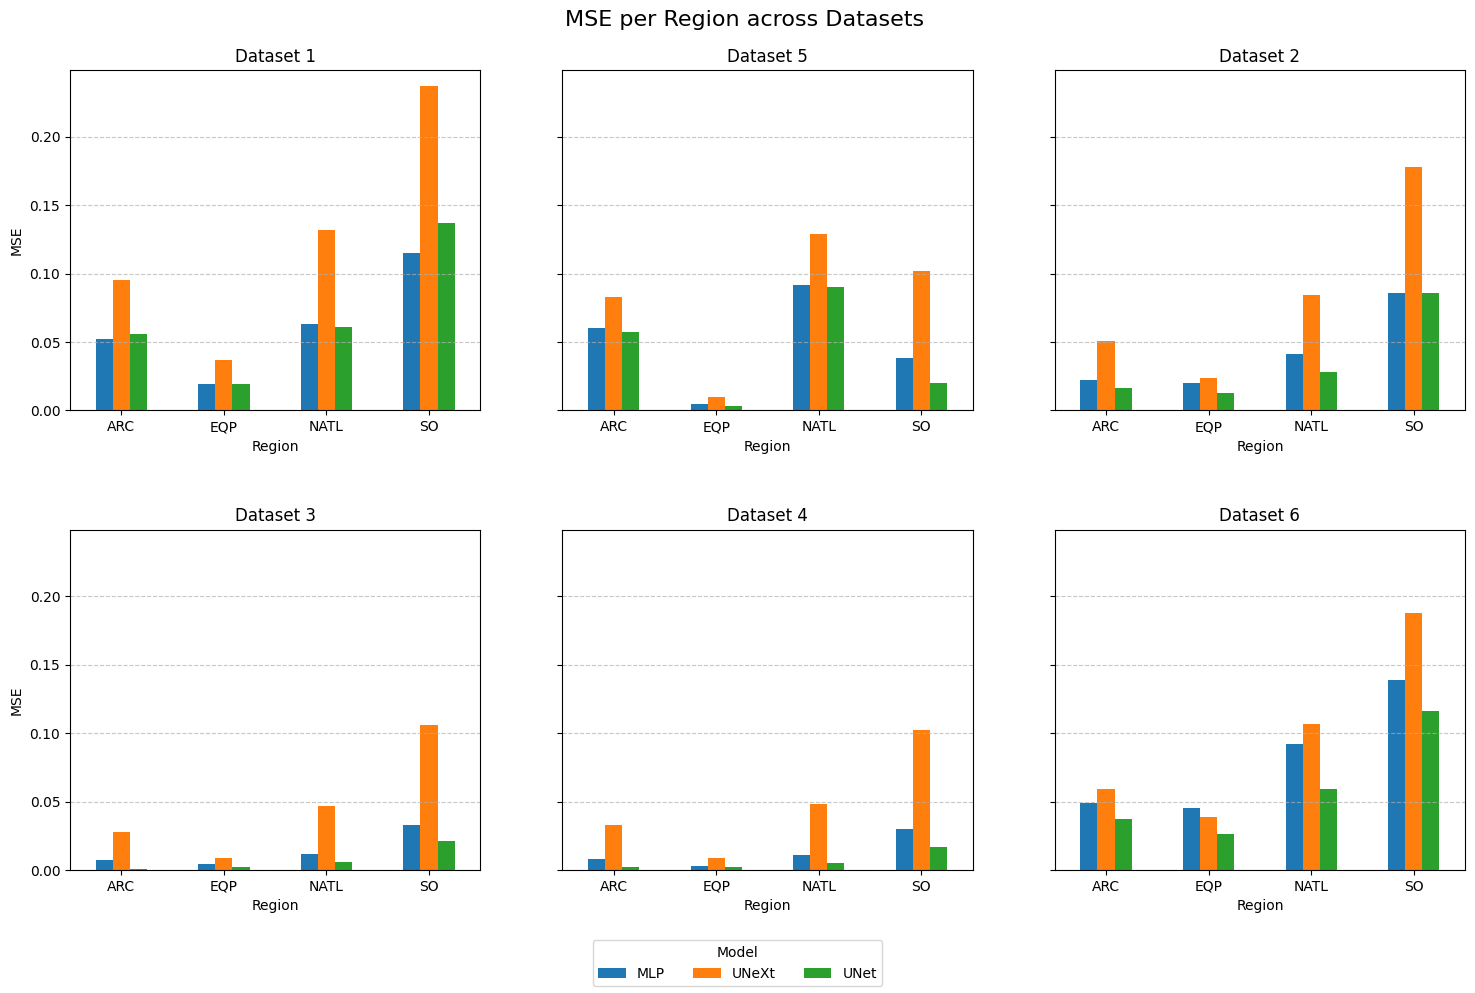

In [4]:
dfs = []
for model, file in files.items():
    dfs.append(parse_file(file, model))

df = pd.concat(dfs)

# Experiments (datasets)
experiments = sorted(df["Experiment"].unique(), key=lambda x: int(re.findall(r"\d+", x)[0]))

# Create subplot grid (2 rows x 3 cols for 6 datasets)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, exp in enumerate(experiments):
    sub = df[df["Experiment"] == exp]
    pivot = sub.pivot(index="Region", columns="Model", values="MSE")
    ax = axes[i]
    pivot.plot(kind="bar", ax=ax, legend=False)
    
    dataset_number = datasetIdMapping[exp]
    ax.set_title(f"Dataset {dataset_number}")
    ax.set_ylabel("MSE")
    ax.set_xlabel("Region")
    ax.tick_params(axis="x", rotation=0)
    
    # Add gridlines
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Collect handles/labels from last plot
handles, labels = axes[-1].get_legend_handles_labels()

# Place one legend under all plots
fig.legend(handles, labels, title="Model", loc="lower center", ncol=3)

# Adjust spacing between rows
plt.subplots_adjust(hspace=0.35, top=0.92, bottom=0.12)

plt.suptitle("MSE per Region across Datasets", fontsize=16)
plt.show()

In [4]:
from utils.plot_style import set_style_width_10
set_style_width_10()   #

path = "../../data/performance/"
dfs = []
for model, file in files.items():
    dfs.append(parse_file(file, model))

df = pd.concat(dfs)

# Extract dataset number
df["Dataset"] = df["Experiment"].str.extract(r"(\d+)")

fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8), sharey=False)
axes1 = axes1.flatten() 

axes1[1].sharey(axes1[0])
axes1[3].sharey(axes1[2])

for i, ds in enumerate(["1", "5", "6", "7"]):
    sub = df[df["Dataset"] == ds]
    pivot = sub.pivot(index="Region", columns="Model", values="MSE")
    ax = axes1[i]
    pivot.plot(kind="bar", ax=ax, legend=False)
    datasetId = "exp" + ds
    ax.set_title(f"Dataset {datasetIdMapping[datasetId]}")
    ax.set_xlabel("Region")
    ax.set_ylabel("MSE [(mol/m²/year)²]")
    ax.tick_params(axis="x", rotation=0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Collect handles/labels from last subplot
handles, labels = axes1[-1].get_legend_handles_labels()

# Place one legend under all plots
fig1.legend(handles, labels, title="Model", loc="lower center", ncol=3)

plt.subplots_adjust(hspace=0.35, wspace=0.08, bottom=0.13, top=0.8)
plt.savefig(path+'basin_performance_1567.png', format='png', dpi=400,  bbox_inches='tight')
# plt.show()
plt.close()

In [5]:
# --- Figure 2: datasets 3 and 8 ---
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, ds in enumerate(["3", "8"]):
    sub = df[df["Dataset"] == ds]
    pivot = sub.pivot(index="Region", columns="Model", values="MSE")
    ax = axes2[i]
    pivot.plot(kind="bar", ax=ax, legend=False)
    datasetId = "exp" + ds
    ax.set_title(f"Dataset {datasetIdMapping[datasetId]}")
    ax.set_xlabel("Region")
    ax.set_ylabel("MSE [(mol/m²/year)²]")
    ax.tick_params(axis="x", rotation=0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)

handles, labels = axes2[-1].get_legend_handles_labels()
fig2.legend(handles, labels, title="Model", loc="lower center", ncol=3)
plt.subplots_adjust(wspace=0.08, bottom=0.25, top=0.8)
plt.savefig(path+'basin_performance_38.png', format='png', dpi=400,  bbox_inches='tight')
# plt.show()
plt.close()

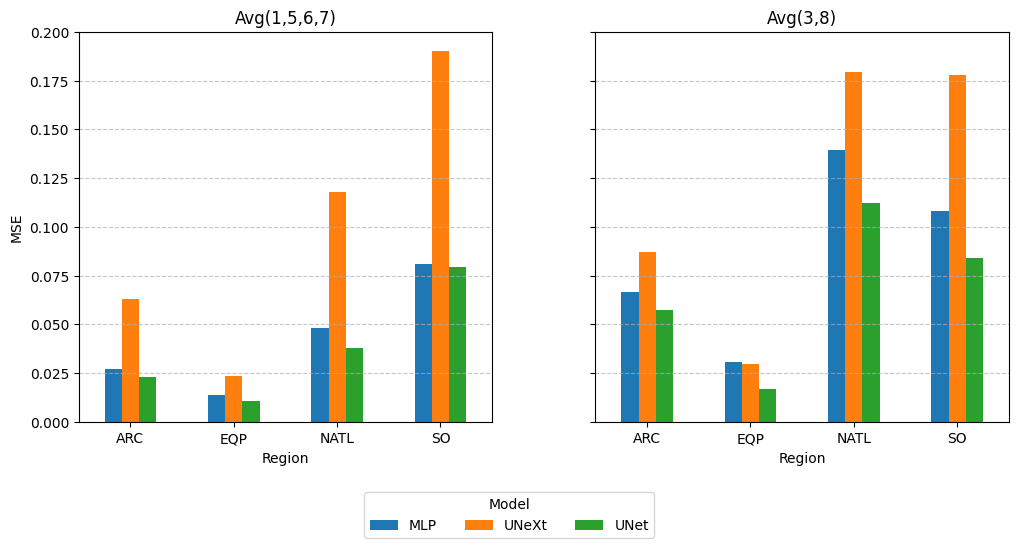

In [38]:
# --- Figure 3: averages ---
# Average(1,5,6,7)
df_avg1 = (
    df[df["Dataset"].isin(["1", "5", "6", "7"])]
    .groupby(["Region", "Model"], as_index=False)["MSE"]
    .mean()
)
df_avg1["Dataset"] = "Avg(1,5,6,7)"

# Average(3,8)
df_avg2 = (
    df[df["Dataset"].isin(["3", "8"])]
    .groupby(["Region", "Model"], as_index=False)["MSE"]
    .mean()
)
df_avg2["Dataset"] = "Avg(3,8)"

df_avg = pd.concat([df_avg1, df_avg2])

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i, ds in enumerate(["Avg(1,5,6,7)", "Avg(3,8)"]):
    sub = df_avg[df_avg["Dataset"] == ds]
    pivot = sub.pivot(index="Region", columns="Model", values="MSE")
    ax = axes3[i]
    pivot.plot(kind="bar", ax=ax, legend=False)
    ax.set_title(ds)
    ax.set_xlabel("Region")
    ax.set_ylabel("MSE")
    ax.tick_params(axis="x", rotation=0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)

handles, labels = axes3[-1].get_legend_handles_labels()
fig3.legend(handles, labels, title="Model", loc="lower center", ncol=3)
plt.subplots_adjust(wspace=0.25, bottom=0.2, top=0.85)
# plt.savefig(path+'performance_averages.png', format='png', dpi=300,  bbox_inches='tight')
plt.show()
plt.close()

In [8]:
path = "../../data/performance/"

# 1) Compute the average over ALL datasets per region and per model
df_avg_all = (
    df.groupby(["Region", "Model"], as_index=False)["MSE"]
      .mean()
)

# 2) Pivot to have Models as columns and Regions as index
pivot_all = df_avg_all.pivot(index="Region", columns="Model", values="MSE")

# 3) Plot single grouped bar plot
fig, ax = plt.subplots(figsize=(10, 6))

pivot_all.plot(kind="bar", ax=ax)

# 4) Styling
ax.set_title("Average MSE per Region Across All Datasets", fontsize=14)
ax.set_xlabel("Region", fontsize=14)
ax.set_ylabel("MSE", fontsize=14)
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", labelsize=14)

# Add grid
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.legend().remove()

# Legend below plot
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Model", loc="upper center", bbox_to_anchor=(0.5, 0.1), ncol=len(pivot_all.columns),
           fontsize=14, title_fontsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)  # more space for legend
plt.savefig(path + 'performance_all_averages.png', format='png', dpi=300, bbox_inches='tight')
plt.close()
